# Image Reward

The introduction and implementations of Image Reward.

Written by Junkun Yuan (yuanjk0921@outlook.com).

Last updated on June 17, 2025; &nbsp; First committed on March 7, 2025.

See more reading papers and notes [here](https://junkunyuan.github.io/reading_papers/reading_papers.html).

**References**

- [**ImageReward: Learning and Evaluating Human Preferences for Text-to-Image Generation** *(NeurIPS 2023)*](https://arxiv.org/pdf/2304.05977): The paper which proposes the Image Reward.

**Contents**
- Image Reward
- PyTorch Implementations

## Image Reward

It trains BLIP on 137K human preference image pairs for image generation and use it to tune diffusion models by Reward Feedback Learning (ReFL).

## PyTorch Implementations

In [ ]:
## --------------------------------------------------------------------------------
## Load model
## --------------------------------------------------------------------------------

## Install package: 'python -m pip install image-reward'
## Download ckpt: https://huggingface.co/THUDM/ImageReward/tree/main

import ImageReward as RM
cache_dir = "ImageReward/"
model = RM.load("ImageReward-v1.0", device="cuda", download_root=cache_dir)

In [ ]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size):
        self.image_paths = image_paths
        self.prompts = prompts

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = []
        prompt = self.prompts[index]
        return image, prompt, file_path
        return image, prompt, file_path
    
## Create a noise image
noise = np.random.randint(0, 256, (3, 224, 224), dtype=np.uint8)
image = Image.fromarray(noise, mode='RGB')
image.save("random_noise.png")

## Build toy data for evaluation
image_paths = ["0.png"] * 8
image_paths += ["1.png"] * 8
image_paths = image_paths + ["random_noise.png"] * 2

prompts = [
    "a bench and a bowl",  # 1
    "a bench and a bird",  # 2
    "a green bench and a blue bowl",  # 3
    "a blue bench and a green bowl",  # 4
    "a bench is on the left of a bowl",  # 5
    "a bowl is on the left of a bench",  # 6
    "Items are neatly arranged in the room.",  # 7
    "Under the blue sky and white clouds, the wind blows the grassland.",  # 8
    "two bears",  # 9
    "a bear and a bear",  # 10
    "a bear and a beer",  # 11
    "a bear is reading books",  # 12
    "two bears are reading books",  # 13
    "three bears are reading books",  # 14
    "A warm family",  # 15
    "A beautiful natural scenery",  # 16
    "two bears",  # 17
    "a bear and a bear"  # 18
]

dataset = ImageDataset(image_paths=image_paths, prompts=prompts, image_size=256)
dataloader = DataLoader(dataset=dataset, batch_size=8, shuffle=False)

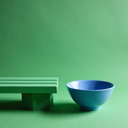

=> prompt: a bench and a bowl, Score: 1.3627185821533203
=> prompt: a bench and a bird, Score: -2.2556676864624023
=> prompt: a green bench and a blue bowl, Score: 1.5103744268417358
=> prompt: a blue bench and a green bowl, Score: 0.10545250028371811
=> prompt: a bench is on the left of a bowl, Score: 1.5319561958312988
=> prompt: a bowl is on the left of a bench, Score: 1.6136332750320435
=> prompt: Items are neatly arranged in the room., Score: -2.1674516201019287
=> prompt: Under the blue sky and white clouds, the wind blows the grassland., Score: -2.2661547660827637


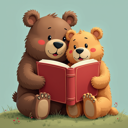

=> prompt: two bears, Score: -0.5952475070953369
=> prompt: a bear and a bear, Score: 0.26699504256248474
=> prompt: a bear and a beer, Score: -2.036942958831787
=> prompt: a bear is reading books, Score: 0.9611136317253113
=> prompt: two bears are reading books, Score: 1.7299389839172363
=> prompt: three bears are reading books, Score: 0.9099398255348206
=> prompt: A warm family, Score: -1.0848459005355835
=> prompt: A beautiful natural scenery, Score: -1.986683964729309


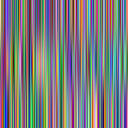

=> prompt: two bears, Score: -2.275449514389038
=> prompt: a bear and a bear, Score: -2.2776293754577637


In [3]:
## --------------------------------------------------------------------------------
## Evaluate
## --------------------------------------------------------------------------------
import torch.nn.functional as F

for idx, (images, prompts, file_paths) in enumerate(dataloader):
    scores = []
    for i in range(len(file_paths)):
        image = Image.open(file_paths[i])
        s = model.score(prompts[i], image)
        scores.append(s)
                    
    ## Show results
    display(image.resize((128, 128)))
    for prompt, score in zip(prompts, scores):
        print(f"=> prompt: {prompt}, Score: {score}")

**Observations:**

From the perspective of semantic alignment evaluation, it is good at identifying <font color=red>objects</font> & <font color=red>numeracy</font> & <font color=red>color</font>, but <font color=red>insensitive</font> to <font color=red>global description</font> & <font color=red>spatial relationship</font>.